# Case Study
This notebook contains a case study on headway bound analysis on WeGo route 55.  It uses observed dwell and travel distributions as well as the current schedule to generate a baseline and then compares several hypothetical scenarios with holding at a predetermined set of stops.

In [1]:
from collections import defaultdict
from copy import deepcopy
from dataclasses import dataclass
from math import exp, log, sqrt
from os import path

from pandas import read_csv
from plotly import graph_objects
from plotly import express
from scipy.special import erfinv

from analysis.policies import *
from analysis.routes import *
from analysis.prob_analysis import *
from analysis.wc_analysis import *

## Plotting Helpers

In [2]:
@dataclass
class GtfsStopConfig(StopConfig):
    """Configuration information required to construct a ```Stop``` with additional information appearing in a GTFS.

    :param stop_id: The stop_id as per the GTFS.
    :param scheduled_departures: The scheduled departure times as per the GTFS.
    """ 
    stop_id: str
    scheduled_departures: list[float]

In [3]:
@dataclass
class RouteConfig(object):
    """Configuration information that defines a route variant under test.
    
    :param name: Name used for identification.
    :param route: List of stops.
    :param start_times: List of times when vehicles start serving the route.
    """ 
    name: str
    route: list[Stop]
    start_times: list[float]

In [4]:
@dataclass
class HeadwayResults(object):
    """Headway experiment results.
    
    :param upper_bound: List of maximum possible headway at each stop.
    :param lower_bound: List of minimum possible headway at each stop.
    """ 
    upper_bound: list[float]
    lower_bound: list[float]

In [5]:
@dataclass
class RouteResults(object):
    """Results from an experiment on one route variant.
    
    :param name: Name used for identification.
    :param route: The route under consideration.
    :param headway: Simulated and analytical headway results for the route.
    """ 
    name: str
    route: list[Stop]
    headway: HeadwayResults

In [6]:
def plot_headway(exp_id: str, results: list[RouteResults], ctrl_pts: dict[str, str]) -> None:
    """Plot simulated and analytical headway bounds.

    :param exp_id: Experiment name used used when saving the figure.
    :param results: List of results for each route under consideration.
    :param ctrl_pts: Dictionary mapping control point stop IDs to human readable names.
    """
    fig = graph_objects.Figure()

    for idx, result in enumerate(results):
        fig.add_trace(graph_objects.Scatter(
            line_color=express.colors.qualitative.T10[idx],
            mode='lines',
            showlegend=False,
            x=[s for s in range(len(result.route))],
            y=result.headway.upper_bound,
        ))
        fig.add_trace(graph_objects.Scatter(
            fill='tonexty',
            line_color=express.colors.qualitative.T10[idx],
            mode='lines',
            name='$' + result.name + '$',
            showlegend=True,
            x=[s for s in range(len(result.route))],
            y=result.headway.lower_bound,
        ))

    xticks = ['' for j in range(len(results[0].route))]
    for idx, stop in enumerate(routes[0].route):
        if stop.stop_id in ctrl_pts:
            xticks[idx] = ctrl_pts[stop.stop_id]
            fig.add_vline(
                x=idx,
                line_width=2,
                line_dash="dash",
                line_color="black",
            )

    fig.update_layout(
        # General style
        font_family="Times New Roman, serif",
        
        # Dimensions
        height=360,
        width=850,
        
        # Axes
        xaxis=dict(
            tickangle=45,
            tickmode='array',
            ticktext=xticks,
            tickvals=[i for i in range(len(xticks))],
        ),
        yaxis=dict(
            title='Headway Bounds (min.)',
            title_standoff=0,
        ),

        # Legend
        legend=dict(
            orientation='h',
            x=0.5,
            xanchor='center',
            y=1.15,
            yanchor='top',
        ),
    )

    fig.show()
    fig.write_image(path.join('figures', f'{exp_id}.pdf'))

In [7]:
def run_experiment(exp_id: str, routes: list[RouteConfig], t_max: float, ctrl_pts: dict[str, str]) -> None:
    """Run an experiment.

    :param exp_id: Experiment name.
    :param routes: The routes (including start times) to compare.
    :param t_max: The cutoff time for simulation and analytical analysis.
    :param ctrl_pts: Dictionary mapping control point stop IDs to human readable names.
    """
    results = []
    for route in routes:
        print(f'Working on {route.name}...')
        headway_ub, headway_lb = headway_bounds(route_factory(route.route), route.start_times, t_max)
        results.append(RouteResults(
            name=route.name,
            route=route.route,
            headway=HeadwayResults(upper_bound=headway_ub, lower_bound=headway_lb),
        ))

    plot_headway(exp_id, results, ctrl_pts)

## Load a Route from a GTFS
Methods to create a route based on a GTFS and historic data.

In [8]:
def get_quantile_log_normal(mu: float, sigma: float, q: float) -> float:
    """Get a quantile's upper boundary (x | p(X < x) = q) for a log-normal distribution parameterized by mu and sigma.

    :param mu: The distribution's logarithm of location.
    :param sigma: The distribution's logarithm of scale.
    :return: The quantile's upper bound.
    """
    return exp(mu + sqrt(2 * sigma ** 2) * erfinv(2 * q - 1))

In [9]:
def get_log_normal_mixture(mu: list[float], sigma: list[float], weights: list[float] | None = None) -> tuple[float]:
    """Get the parameters of a log normal mixture approximated by log normal distribution.
    
    :param mu: List of logarithms of location for every log-normal distribution in the mixture.
    :param sigma: List of logarithms of scale for every log-normal distribution in the mixture.
    :param weight: List of weights for each log-normal distribution in the mixture.
    """
    assert len(mu) == len(sigma)
    if weights is None:
        w = [1 / len(mu) for _ in range(len(mu))]
    else:
        assert len(weights) == len(mu)
        w = weights

    # Calculate moments
    m1 = 0
    m2 = 0
    for i in range(len(mu)):
        m1 += w[i] * exp(mu[i] + (sigma[i] ** 2) / 2)
        m2 += (w[i] ** 2) * exp(2 * mu[i] + 2 * sigma[i] ** 2)
    temp = 0
    for i in range(len(sigma)):
        for j in range(i+1,len(sigma)):
            temp += (w[i] * w[j]) * exp(mu[i] + mu[j] + 0.5 * (sigma[i] ** 2 + sigma[j] ** 2))
    m2 = m2 + 2 * temp

    # Calculate new parameters
    sigma = sqrt(log(m2/(m1 ** 2)))
    mu = log(m1) - (sigma ** 2) / 2
    return mu, sigma

In [10]:
def load_route_from_gtfs(route_id: int, service_day: str) -> tuple[list[GtfsStopConfig], list[float]]:
    """Create a route template from a GTFS.

    .. note ::
        This function makes some assumptions about the structure of routes in the GTFS.  For example we assume that earliest departure
        along a route starts in direction "1", not "0".

    :param route_id: The route id in the GTFS.
    :param service_day: The service day in the GTFS the route template will be based on.
    :returns: List of stop configurations in order of service.
    :raises ValueError:
    """
    calendar = read_csv(path.join('gtfs', 'calendar.txt'))
    trips = read_csv(path.join('gtfs', 'trips.txt'))
    stops = read_csv(path.join('gtfs', 'stops.txt'))
    stop_times = read_csv(path.join('gtfs', 'stop_times.txt'))

    # Get service_id for selected day
    active_service_ids = calendar[calendar[service_day] == 1].service_id
    if len(active_service_ids) == 0:
        raise ValueError(f'No service on {service_day} in GTFS!')
    elif len(active_service_ids) > 1:
        raise ValueError(f'Multiple services on {service_day} in GTFS: multiple services are currently not supported!')
    service_id = active_service_ids.iloc[0]

    # Get the trips we care about
    trips = trips[(trips.service_id == service_id) & (trips.route_id == route_id)]

    # Map patterns (unique sequences of stops) to trips
    patterns_by_direction_id = defaultdict(set)
    trips_by_pattern = defaultdict(set)
    for block_id in [int(b) for b in trips.block_id.unique()]:
        for trip_id in [int(t) for t in trips[trips.block_id == block_id].trip_id.unique()]:
            pattern = tuple(stop_times[stop_times.trip_id == trip_id].sort_values(by='stop_sequence').stop_id)
            patterns_by_direction_id[trips[trips.trip_id == trip_id].direction_id.iloc[0].item()].add(pattern)
            trips_by_pattern[pattern].add(trip_id)

    # Select the most common pattern for each direction ID (we're ignoring weird, one-off patterns)
    selected_pattern_by_direction_id = {}
    for direction_id, patterns in patterns_by_direction_id.items():
        selected_pattern = max(patterns, key=lambda pattern: len(trips_by_pattern[pattern]))
        selected_pattern_by_direction_id[direction_id] = selected_pattern

    # Map stop_id and direction_id to Stop objects
    # Note: we assume direction_id=1, is the starting leg of the route
    stop_info = []
    for direction_id in list(selected_pattern_by_direction_id.keys())[::-1]:
        # Last stop in pattern is duplicated, since it is the first stop in the next direction
        for stop_id in selected_pattern_by_direction_id[direction_id][:-1]:
            stop_info.append(GtfsStopConfig(
                tau=None,
                delta=None,
                policy=BolehPolicy,
                policy_args={},
                stop_id=stop_id,
                scheduled_departures=[],
            ))

    # Get scheduled departures for each stop
    scheduled_departures_by_stop_id = defaultdict(list)
    block_start_times: dict[float] = {}
    for pattern in selected_pattern_by_direction_id.values():
        for trip_id in trips_by_pattern[pattern]:
            stop_ids = tuple(stop_times[stop_times.trip_id == trip_id].sort_values(by='stop_sequence').stop_id)
            departure_times = tuple(stop_times[stop_times.trip_id == trip_id].sort_values(by='stop_sequence').departure_time)
            departure_times = tuple(d.strip().split(':') for d in departure_times)
            departure_times = tuple(int(h) * 60 + int(m) + int(s) / 60 for h, m, s in departure_times)
            for stop_id, departure_time in zip(stop_ids[:-1], departure_times[:-1]):
                scheduled_departures_by_stop_id[stop_id].append(departure_time)
            block_id = trips[trips.trip_id == trip_id].block_id.iloc[0].item()
            if block_id in block_start_times:
                block_start_times[block_id] = min(departure_times[0], block_start_times[block_id])
            else:
                block_start_times[block_id] = block_id
    for stop_id, scheduled_departures in scheduled_departures_by_stop_id.items():
        scheduled_departures.sort()

    # Get starting times
    block_start_times = sorted(list(block_start_times.values()))

    # Normalize all times so that the first block starts at t=0
    offset = block_start_times[0]
    for idx, time in enumerate(block_start_times):
        block_start_times[idx] -= offset
        # For some reason some blocks randomly start in the afternoon.
        # This messes up our metrics since we can't calculate headway until all the initial vehicles have departed.
        if block_start_times[idx] >= 200:
            block_start_times = block_start_times[:idx]
            break
    for departure_times in scheduled_departures_by_stop_id.values():
        for idx, _ in enumerate(departure_times):
            departure_times[idx] -= offset

    # Add departure times to each stop config
    for stop in stop_info:
        stop.scheduled_departures = scheduled_departures_by_stop_id[stop.stop_id]

    # Remove start times from first stop's scheduled departures
    for start_time in block_start_times:
        stop_info[0].scheduled_departures.remove(start_time)
    
    return stop_info, block_start_times

In [11]:
def load_times(route: list[GtfsStopConfig], service_day: str, lower_quantile: float, upper_quantile: float) -> list[GtfsStopConfig]:
    """Load the travel and dwell times for a route defined in the GTFS.

    .. warning ::
        This function modifies the route argument in addition to returning a route.
    
    :param route: List of stop configuration in order of stops.
    :param service_day: The day of the weak whose data will be used to calculate the parameters.
    :lower_quantile: The lower quantile of observed travel and dwell times to consider.
    :upper_quantile: The uppler quantile of observed travel and dwell times to consider.
    :return: The route with updated travel and dwell time bounds.
    """
    travel_times = read_csv(path.join('data', 'travel_times.csv'))
    alight_rates = read_csv(path.join('data', 'alight_rates.csv'))
    demand_rates = read_csv(path.join('data', 'demand_rates_monday.csv'))

    for stop in route:
        tt = travel_times[(travel_times.day_of_week == service_day) & (travel_times.from_stop_id == stop.stop_id)]
        tt_mu = list(tt.mean_log_travel_time_s)
        tt_sigma = list(tt.std_log_travel_time_s)
        mu, sigma = get_log_normal_mixture(tt_mu, tt_sigma)
        lower = get_quantile_log_normal(mu, sigma, lower_quantile) / 60
        upper = get_quantile_log_normal(mu, sigma, upper_quantile) / 60
        stop.tau = (lower, upper)

        ar = alight_rates[alight_rates.STOP_ID == stop.stop_id]
        ar = list(ar.ALIGHT_RATE)
        dr = demand_rates[demand_rates.STOP_ID == stop.stop_id]
        dr = list(dr.HOURLY_DEMAND)

        weights = []
        for a, d in zip(ar, dr):
            weights.extend([10 / len(ar), 2 * a / len(ar), 3.5 * d / len(dr)])
        mu, sigma = get_log_normal_mixture([0 for _ in range(len(weights))], [0.1 for _ in range(len(weights))], weights)
        lower = get_quantile_log_normal(mu, sigma, lower_quantile) / 60
        upper = get_quantile_log_normal(mu, sigma, upper_quantile) / 60
        stop.delta = (lower, upper)

    return route

In [12]:
BASE_ROUTE, START_TIMES = load_route_from_gtfs(route_id=55, service_day='monday')
BASE_ROUTE = load_times(BASE_ROUTE, service_day='Monday', lower_quantile=0.05, upper_quantile=0.95)

# Evaluate Variants of the Route under Different Holding Policies
We create four route variants and compute their headway bounds:
1. Schedule-driven route: use the current stop schedules from the GTFS at the terminal and midpoint to hold buses,
2. Headway-driven holding at MXITHOMP and MXOTHOMP with 30 minutes maximum circuit holding time,
3. Headway-driven holding at MXIGLENG, MXITHOMP, MXIBELL, and MXOTHOMP with 30 minutes maximum circuit holding time,
4. Unbounded headway-driven holding at each stop.

Working on \pi\texttt{SCH}\;\text{(Baseline)}...
Working on \pi\texttt{DYN}\;\text{(All ctrl. pts.)}...
Working on \pi\texttt{DYN}\;\text{(Select ctrl. pts.)}...
Working on \pi\texttt{DYN}\;@\;\text{Every Stop}...


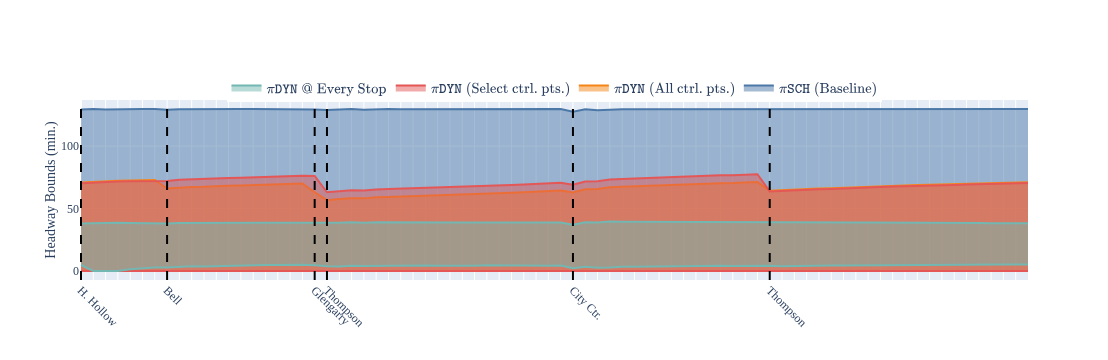

In [13]:
# Schedule-driven route
SCHED_ROUTE= deepcopy(BASE_ROUTE)
for i in range(len(SCHED_ROUTE)):
    if SCHED_ROUTE[i].stop_id in ['HICHICNN', 'MCC4_15']:
        SCHED_ROUTE[i].policy = ScheduleDrivenPolicy
        SCHED_ROUTE[i].policy_args = {'schedule': SCHED_ROUTE[i].scheduled_departures}

# Schedule-driven at terminals, headway-driven at MXIBELL, MXIGLENG, MXITHOMP, and MXOTHOMP
HEADWAY4 = deepcopy(BASE_ROUTE)
for i in range(len(HEADWAY4)):
    if HEADWAY4[i].stop_id in ['MXIBELL', 'MXIGLENG', 'MXITHOMP', 'MXOTHOMP']:
        HEADWAY4[i].policy = HeadwayDrivenPolicy
        HEADWAY4[i].policy_args = {'activation_ratio': 0.75, 'max_holding': 7.5}

# Schedule-driven at terminals, headway-driven at MXITHOMP and MXOTHOMP
HEADWAY2 = deepcopy(BASE_ROUTE)
for i in range(len(HEADWAY2)):
    if HEADWAY2[i].stop_id in [ 'MXITHOMP', 'MXOTHOMP']:
        HEADWAY2[i].policy = HeadwayDrivenPolicy
        HEADWAY2[i].policy_args = {'activation_ratio': 0.75, 'max_holding': 15.0}

# Headway-driven at all stops
HEADWAY_ROUTE= deepcopy(BASE_ROUTE)
for i in range(len(HEADWAY_ROUTE)):
    HEADWAY_ROUTE[i].policy = HeadwayDrivenPolicy
    HEADWAY_ROUTE[i].policy_args = {'activation_ratio': 1, 'max_holding': float('inf')}

routes = [
    RouteConfig(name=r'\pi\texttt{SCH}\;\text{(Baseline)}', route=BASE_ROUTE, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}\;\text{(All ctrl. pts.)}', route=HEADWAY4, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}\;\text{(Select ctrl. pts.)}', route=HEADWAY2, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}\;@\;\text{Every Stop}', route=HEADWAY_ROUTE, start_times=START_TIMES),
]

run_experiment(
    exp_id='route55',
    routes=routes,
    t_max=60 * 24 * 7,
    ctrl_pts=dict(
        HICHICNN='H. Hollow',
        MXIBELL='Bell',
        MXIGLENG='Glengarry',
        MXITHOMP='Thompson',
        MCC4_15='City Ctr.',
        MXOTHOMP='Thompson',
    ),
)